# Conditional 3D Latent Diffusion Model Training

This notebook trains a conditional diffusion model to predict future CT fractions (Fraction N) based on the first fraction (Fraction 1). 
It operates on 3D latent representations generated by a VAE.

**Key Features:**
- **Framework**: PyTorch + MONAI
- **Model**: 3D Diffusion UNet (`monai.networks.nets.DiffusionModelUNet`)
- **Conditioning**: Channel concatenation (fractions 1 + N)
- **Hardware**: Multi-GPU training using `torch.nn.DataParallel` (optimized for 4x A100 40GB)


In [1]:
import os
import glob
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# MONAI
from monai.networks.nets import DiffusionModelUNet
from monai.networks.schedulers import DDPMScheduler
from monai.utils import set_determinism

set_determinism(42)

In [2]:
# Config / Hyperparameters
config = {
    "data_dir": "/net/tscratch/people/plgpiotreksl/maisi_vae_latent",
    "save_dir": "/net/tscratch/people/plgpiotreksl/models/conditional_diffusion_unet",
    "batch_size": 16,        # Adjust based on VRAM. 16 per batch total -> 4 per GPU
    "n_epochs": 300,
    "lr": 1e-4,
    "val_interval": 5,
    "num_workers": 8,
    "num_train_timesteps": 1000,
    "spatial_dims": 3,
    "latent_channels": 4,   # 4 channels from VAE
    "model_channels": (64, 128, 256, 512),
    "attention_levels": (False, False, True, True),
    "num_res_blocks": 2,
    "num_head_channels": 64,
}

os.makedirs(config["save_dir"], exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU count: {torch.cuda.device_count()}")

Using device: cuda
GPU count: 1


## 1. Dataset Class

In [3]:
class LatentPairsDataset(Dataset):
    """Dataset that pairs fraction_1 with fraction_n for each patient."""
    
    def __init__(self, root_dir, patient_split=None):
        """
        Args:
            root_dir: Path to latent encodings
            patient_split: List of patient IDs to include, or None for all
        """
        self.root_dir = root_dir
        self.pairs = []
        
        # Find all patient folders
        all_patient_dirs = sorted(glob.glob(os.path.join(root_dir, 'Patient_*')))
        
        # Filter by patient split if provided
        if patient_split is not None:
            patient_dirs = [d for d in all_patient_dirs if os.path.basename(d) in patient_split]
        else:
            patient_dirs = all_patient_dirs
        
        for p_dir in patient_dirs:
            p_id = os.path.basename(p_dir)
            # Find fraction 1
            f1_files = glob.glob(os.path.join(p_dir, f'{p_id}_fraction_1_.pt'))
            if not f1_files:
                f1_files = glob.glob(os.path.join(p_dir, f'{p_id}_fraction_1.pt'))
            
            if not f1_files:
                continue
                
            f1_path = f1_files[0]
            
            # Find all other fractions
            all_fractions = sorted(glob.glob(os.path.join(p_dir, f'{p_id}_fraction_*.pt')))
            for f_path in all_fractions:
                if f_path == f1_path:
                    continue
                # Add pair (fraction_1, fraction_n)
                self.pairs.append((f1_path, f_path))
                
        print(f"Found {len(self.pairs)} pairs across {len(patient_dirs)} patients.")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        f1_path, fn_path = self.pairs[idx]
        
        # Load latents
        # Use safe loading if possible, or weights_only=False if trusted
        try:
            f1_data = torch.load(f1_path, map_location='cpu', weights_only=False)
            fn_data = torch.load(fn_path, map_location='cpu', weights_only=False)
        except Exception as e:
            print(f"Error loading {f1_path} or {fn_path}: {e}")
            # Return dummy or handle error appropriately in production
            # For now, let's just re-raise or skip (not ideal in __getitem__)
            raise e
        
        # Extract tensor from dict if necessary
        if isinstance(f1_data, dict):
            f1 = f1_data['latent'] if 'latent' in f1_data else f1_data.get('z')
        else:
            f1 = f1_data
            
        if isinstance(fn_data, dict):
            fn = fn_data['latent'] if 'latent' in fn_data else fn_data.get('z')
        else:
            fn = fn_data
        
        # Ensure correct shape [C, D, H, W]
        # Some VAEs output [1, C, D, H, W] or [1, D, H, W]
        
        # Remove batch dim if present
        if f1.ndim == 5 and f1.shape[0] == 1:
            f1 = f1.squeeze(0)
        if fn.ndim == 5 and fn.shape[0] == 1:
            fn = fn.squeeze(0)
            
        # Add channel dim if missing (single channel case, though unlikely for VAE latent)
        if f1.ndim == 3:
            f1 = f1.unsqueeze(0)
        if fn.ndim == 3:
            fn = fn.unsqueeze(0)
        
        # Ensure tensors are float32
        f1 = f1.float()
        fn = fn.float()
            
        return f1, fn

## 2. Prepare DataLoaders

In [4]:
# Split patients
all_patient_dirs = sorted(glob.glob(os.path.join(config['data_dir'], 'Patient_*')))
all_patients = [os.path.basename(d) for d in all_patient_dirs]

# Simple split
np.random.seed(42)
np.random.shuffle(all_patients)

n_train = int(0.8 * len(all_patients))
n_val = int(0.1 * len(all_patients))

train_patients = all_patients[:n_train]
val_patients = all_patients[n_train:n_train+n_val]
test_patients = all_patients[n_train+n_val:]

print(f"Train: {len(train_patients)}, Val: {len(val_patients)}, Test: {len(test_patients)}")

train_ds = LatentPairsDataset(config['data_dir'], patient_split=train_patients)
val_ds = LatentPairsDataset(config['data_dir'], patient_split=val_patients)

train_loader = DataLoader(
    train_ds, 
    batch_size=config['batch_size'], 
    shuffle=True, 
    num_workers=config['num_workers'],
    pin_memory=True
)
val_loader = DataLoader(
    val_ds, 
    batch_size=config['batch_size'], 
    shuffle=False, 
    num_workers=config['num_workers'],
    pin_memory=True
)

# Check shape
f1, fn = next(iter(train_loader))
print(f"Batch Shape: {f1.shape}")

Train: 57, Val: 7, Test: 8
Found 1561 pairs across 57 patients.
Found 185 pairs across 7 patients.
Batch Shape: torch.Size([16, 4, 120, 120, 32])


## 3. Model Definition

We use `DiffusionModelUNet` from MONAI.
- `in_channels=8`: We concatenate the noisy input (4 channels) + the condition (4 channels).
- `out_channels=4`: We predict the noise (4 channels).

In [ ]:
model = DiffusionModelUNet(
    spatial_dims=config["spatial_dims"],
    in_channels=config["latent_channels"] * 2,  # 4 for input + 4 for condition
    out_channels=config["latent_channels"],     # 4 for noise prediction
    channels=config["model_channels"],
    attention_levels=config["attention_levels"],
    num_res_blocks=config["num_res_blocks"],
    num_head_channels=config["num_head_channels"],
)

# Wrap in DataParallel for Multi-GPU
if torch.cuda.device_count() > 1:
    print(f"Wrapping model in DataParallel on {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

from diffusers import DDPMScheduler, DDIMScheduler

scheduler = DDPMScheduler(
    num_train_timesteps=config["num_train_timesteps"],
    beta_schedule="squaredcos_cap_v2",  # Smoother noise transition
    prediction_type="sample",           # Predict clean image (x_0) directly
    clip_sample=False                   # IMPORTANT: Latents are not in [-1, 1]
)

optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"])
scaler = torch.cuda.amp.GradScaler()


## 4. Training Loop

In [ ]:

first_batch = next(iter(train_loader))
_, first_fn = first_batch
LATENT_STD = first_fn.flatten().std().item()
LATENT_SCALE_FACTOR = 1.0 / LATENT_STD

print(f"Calculated Latent Std: {LATENT_STD:.4f}")
print(f"Using Scale Factor: {LATENT_SCALE_FACTOR:.4f}")

# Metrics storage
epoch_loss_values = []
val_loss_values = []

for epoch in range(config["n_epochs"]):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['n_epochs']}")
    
    for f1, fn in progress_bar:
        f1 = f1.to(device)
        fn = fn.to(device)
        
        f1_scaled = f1 * LATENT_SCALE_FACTOR
        fn_scaled = fn * LATENT_SCALE_FACTOR
        
        optimizer.zero_grad()
        
     
        timesteps = torch.randint(
            0, scheduler.num_train_timesteps, (fn.shape[0],), device=device
        ).long()
        
        # Add Noise
        noise = torch.randn_like(fn_scaled)
        noisy_fn = scheduler.add_noise(original_samples=fn_scaled, noise=noise, timesteps=timesteps)
        
        # Concatenate: [Noisy_Target, Condition]
        model_input = torch.cat([noisy_fn, f1_scaled], dim=1)
        
        with torch.cuda.amp.autocast():
            model_output = model(model_input, timesteps=timesteps)
            loss = F.mse_loss(model_output, fn_scaled)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})
    
    # Validation
    avg_loss = epoch_loss / len(train_loader)
    epoch_loss_values.append(avg_loss)
    
    if (epoch + 1) % config["val_interval"] == 0:
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for f1, fn in val_loader:
                f1 = f1.to(device)
                fn = fn.to(device)
                
                f1_scaled = f1 * LATENT_SCALE_FACTOR
                fn_scaled = fn * LATENT_SCALE_FACTOR
                
                timesteps = torch.randint(
                    0, scheduler.num_train_timesteps, (fn.shape[0],), device=device
                ).long()
                noise = torch.randn_like(fn_scaled)
                noisy_fn = scheduler.add_noise(original_samples=fn_scaled, noise=noise, timesteps=timesteps)
                
                model_input = torch.cat([noisy_fn, f1_scaled], dim=1)
                
                with torch.cuda.amp.autocast():
                    model_output = model(model_input, timesteps=timesteps)
                    loss = F.mse_loss(model_output, fn_scaled)
                
                val_loss += loss.item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_loss_values.append(avg_val_loss)
        print(f"Epoch {epoch+1} - Train Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        
        torch.save(model.state_dict(), os.path.join(config["save_dir"], f"model_epoch_{epoch+1}.pt"))


Calculated Latent Std: 0.4432
Using Scale Factor: 2.2562


Epoch 1/300:   0%|          | 0/98 [00:00<?, ?it/s]/net/tscratch/people/plgpiotreksl/env-test/lib/python3.11/site-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/net/tscratch/people/plgpiotreksl/slurm_jobdir/2148636/tmp.t0004/ipykernel_2708579/539225206.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 5/300: 100%|██████████| 98/98 [02:17<00:00,  1.41s/it, loss=0.175]
/net/tscratch/people/plgpiotreksl/slurm_jobdir/2148636/tmp.t0004/ipykernel_2708579/539225206.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. P

Epoch 5 - Train Loss: 0.1805, Val Loss: 0.1724


Epoch 10/300: 100%|██████████| 98/98 [02:17<00:00,  1.40s/it, loss=0.145] 


Epoch 10 - Train Loss: 0.1504, Val Loss: 0.1529


Epoch 15/300: 100%|██████████| 98/98 [02:17<00:00,  1.40s/it, loss=0.13]  


Epoch 15 - Train Loss: 0.1285, Val Loss: 0.1423


Epoch 16/300:  17%|█▋        | 17/98 [00:24<01:53,  1.40s/it, loss=0.102] 

## 5. Sampling / Inference Test

In [ ]:

import os
import torch
checkpoint_path = os.path.join("/net/tscratch/people/plgpiotreksl/models/conditional_diffusion_unetv2","model_best.pt")
if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint: {checkpoint_path}")
    
    state_dict = torch.load(checkpoint_path, map_location="cpu")
   
    is_model_parallel = isinstance(model, torch.nn.DataParallel)
        
    is_ckpt_parallel = any(k.startswith("module.") for k in state_dict.keys())
    
    if is_model_parallel and not is_ckpt_parallel:
        new_state_dict = {f"module.{k}": v for k, v in state_dict.items()}
        model.load_state_dict(new_state_dict)
        
    elif not is_model_parallel and is_ckpt_parallel:
        new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
        model.load_state_dict(new_state_dict)
        
    else:
        model.load_state_dict(state_dict)
    
else:
    print(f"WARNING: Checkpoint not found at {checkpoint_path}")
model = model.to(device)
model.eval()  # Set to evaluation mode for inference


first_batch = next(iter(train_loader))
_, first_fn = first_batch
LATENT_STD = first_fn.flatten().std().item()
LATENT_SCALE_FACTOR = 1.0 / LATENT_STD
print(f"Recalculated LATENT_SCALE_FACTOR: {LATENT_SCALE_FACTOR:.4f}")

Starting sampling...


Sampling: 100%|██████████| 1000/1000 [02:03<00:00,  8.10it/s]


Sampling complete.
MSE: 0.144876 | MAE: 0.158229 | Corr: 0.6604


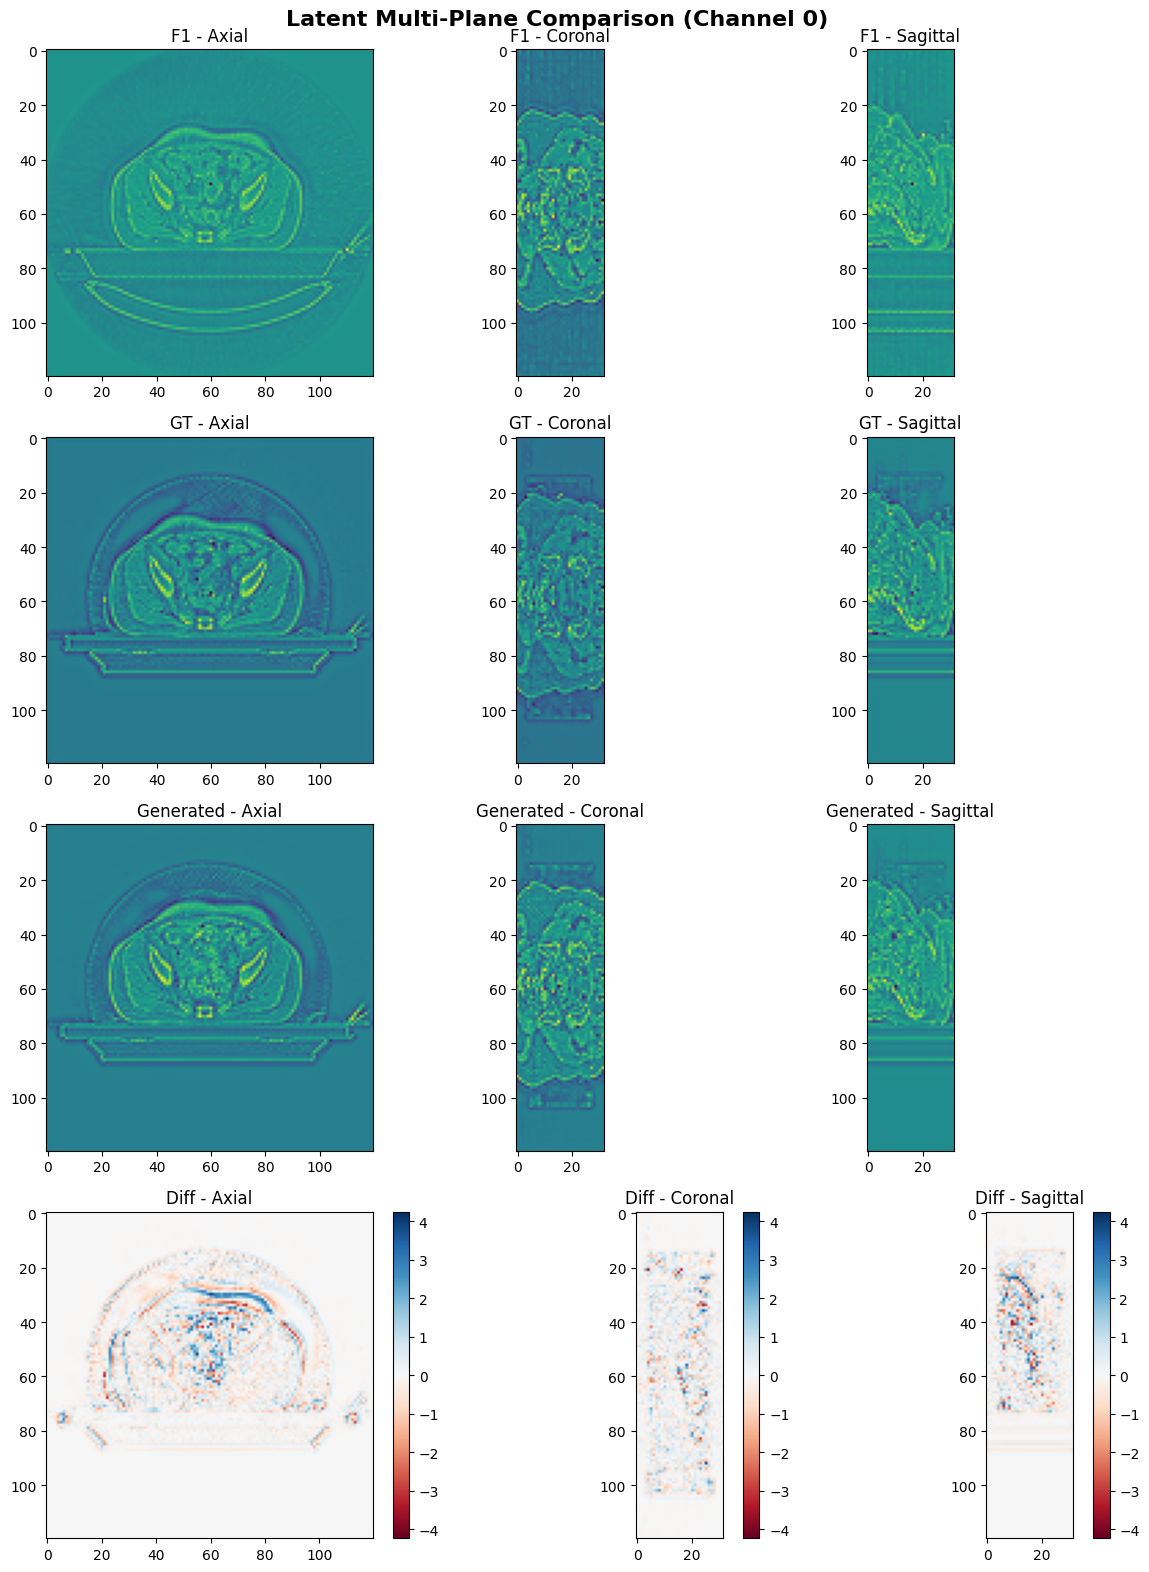

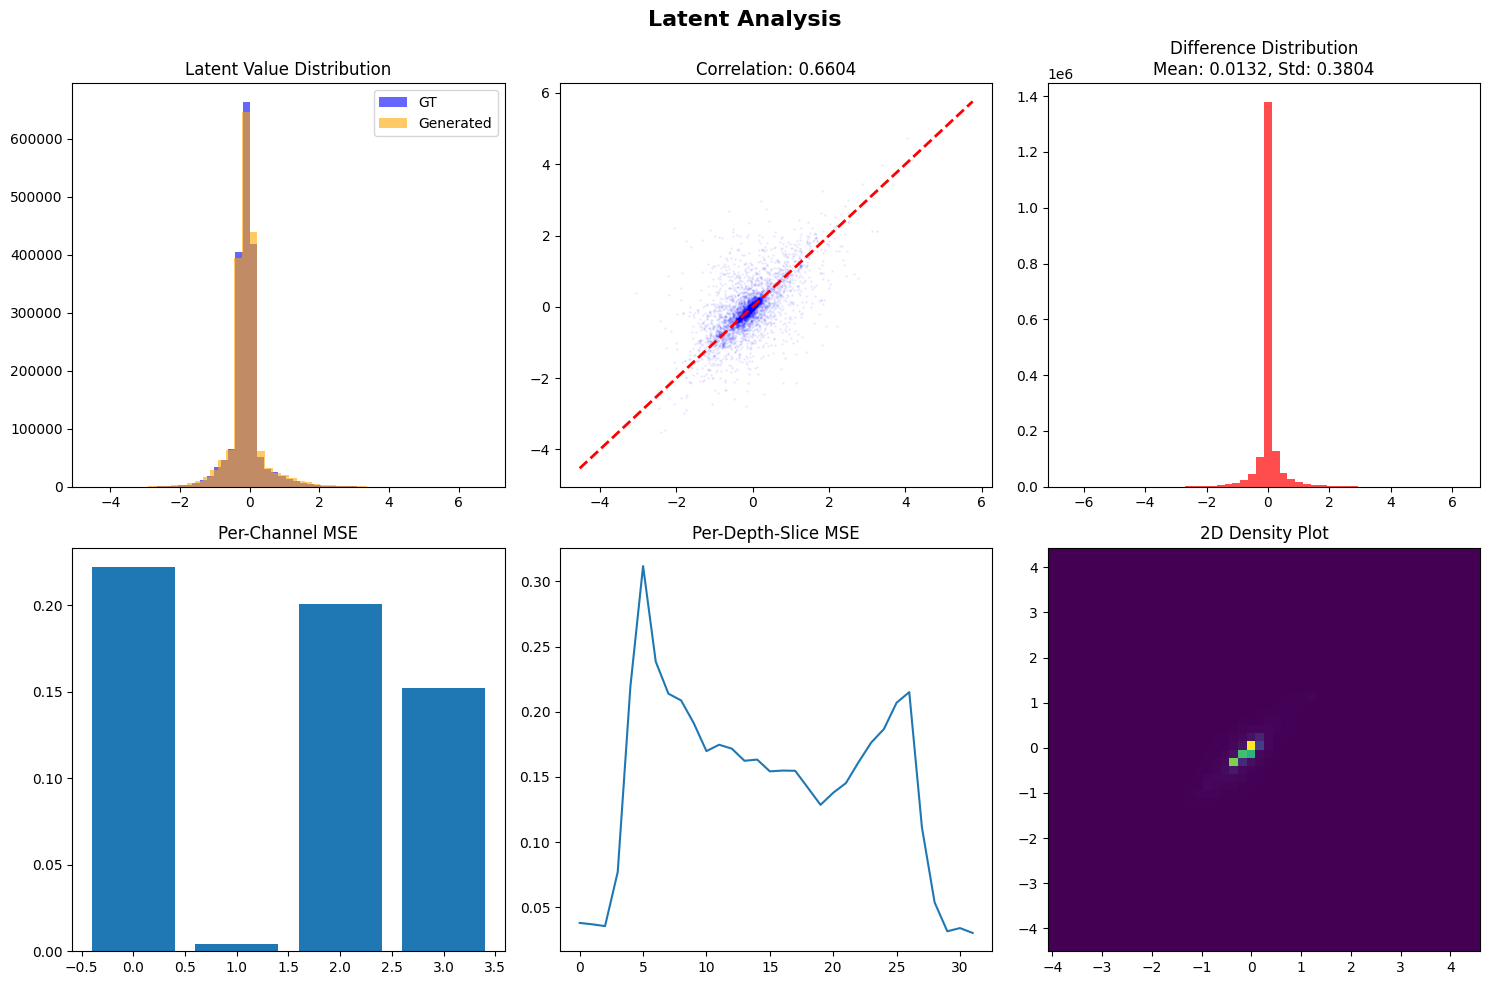

In [7]:
# === SAMPLING ===
model.eval()

# Get one sample
val_iter = iter(val_loader)
f1, fn = next(val_iter)
f1_sample = f1[0:1].to(device)
gt_sample = fn[0:1].to(device)

# 1. Scale Condition
f1_sample_scaled = f1_sample * LATENT_SCALE_FACTOR

# 2. Start from Noise
current_img = torch.randn(1, 4, 120, 120, 32).to(device)

print("Starting sampling...")
with torch.no_grad():
    for t in tqdm(scheduler.timesteps, desc="Sampling"):
        model_input = torch.cat([current_img, f1_sample_scaled], dim=1)
        
        if isinstance(model, nn.DataParallel):
            model_output = model.module(model_input, timesteps=torch.tensor([t], device=device))
        else:
            model_output = model(model_input, timesteps=torch.tensor([t], device=device))
            
        # Denoise step - Robust Unpacking
        step_output = scheduler.step(model_output, t, current_img)
        
        if hasattr(step_output, 'prev_sample'):
            current_img = step_output.prev_sample
        elif isinstance(step_output, dict):
            current_img = step_output['prev_sample']
        elif isinstance(step_output, tuple):
            current_img = step_output[0]
        else:
            # Fallback if it is the Tensor itself
            current_img = step_output

print("Sampling complete.")

# 3. INVERSE SCALE
generated_sample = current_img / LATENT_SCALE_FACTOR

# === VISUALIZATION ===
import torch.nn.functional as F
import matplotlib.pyplot as plt

mse = F.mse_loss(generated_sample, gt_sample).item()
mae = F.l1_loss(generated_sample, gt_sample).item()
gen_flat = generated_sample.flatten().cpu()
gt_flat = gt_sample.flatten().cpu()
correlation = torch.corrcoef(torch.stack([gen_flat, gt_flat]))[0, 1].item()

print(f"MSE: {mse:.6f} | MAE: {mae:.6f} | Corr: {correlation:.4f}")

channel = 0
center_d = gt_sample.shape[4] // 2
center_h = gt_sample.shape[2] // 2
center_w = gt_sample.shape[3] // 2

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.suptitle(f'Latent Multi-Plane Comparison (Channel 0)', fontsize=16, fontweight='bold')

# Row 1: Condition (f1)
axes[0, 0].imshow(f1_sample[0, channel, :, :, center_d].cpu(), cmap='viridis')
axes[0, 0].set_title('F1 - Axial')
axes[0, 1].imshow(f1_sample[0, channel, center_h, :, :].cpu(), cmap='viridis')
axes[0, 1].set_title('F1 - Coronal')
axes[0, 2].imshow(f1_sample[0, channel, :, center_w, :].cpu(), cmap='viridis')
axes[0, 2].set_title('F1 - Sagittal')

# Row 2: Ground Truth
axes[1, 0].imshow(gt_sample[0, channel, :, :, center_d].cpu(), cmap='viridis')
axes[1, 0].set_title('GT - Axial')
axes[1, 1].imshow(gt_sample[0, channel, center_h, :, :].cpu(), cmap='viridis')
axes[1, 1].set_title('GT - Coronal')
axes[1, 2].imshow(gt_sample[0, channel, :, center_w, :].cpu(), cmap='viridis')
axes[1, 2].set_title('GT - Sagittal')

# Row 3: Generated
axes[2, 0].imshow(generated_sample[0, channel, :, :, center_d].cpu(), cmap='viridis')
axes[2, 0].set_title('Generated - Axial')
axes[2, 1].imshow(generated_sample[0, channel, center_h, :, :].cpu(), cmap='viridis')
axes[2, 1].set_title('Generated - Coronal')
axes[2, 2].imshow(generated_sample[0, channel, :, center_w, :].cpu(), cmap='viridis')
axes[2, 2].set_title('Generated - Sagittal')

# Row 4: Diff
diff_axial = (generated_sample[0, channel, :, :, center_d] - gt_sample[0, channel, :, :, center_d]).cpu()
diff_coronal = (generated_sample[0, channel, center_h, :, :] - gt_sample[0, channel, center_h, :, :]).cpu()
diff_sagittal = (generated_sample[0, channel, :, center_w, :] - gt_sample[0, channel, :, center_w, :]).cpu()

max_diff = max(diff_axial.abs().max(), diff_coronal.abs().max(), diff_sagittal.abs().max())

im0 = axes[3, 0].imshow(diff_axial, cmap='RdBu', vmin=-max_diff, vmax=max_diff)
axes[3, 0].set_title('Diff - Axial')
plt.colorbar(im0, ax=axes[3, 0], fraction=0.046)
im1 = axes[3, 1].imshow(diff_coronal, cmap='RdBu', vmin=-max_diff, vmax=max_diff)
axes[3, 1].set_title('Diff - Coronal')
plt.colorbar(im1, ax=axes[3, 1], fraction=0.046)
im2 = axes[3, 2].imshow(diff_sagittal, cmap='RdBu', vmin=-max_diff, vmax=max_diff)
axes[3, 2].set_title('Diff - Sagittal')
plt.colorbar(im2, ax=axes[3, 2], fraction=0.046)

plt.tight_layout()
plt.show()

# Analysis Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f'Latent Analysis', fontsize=16, fontweight='bold')

axes[0, 0].hist(gt_flat.numpy(), bins=50, alpha=0.6, label='GT', color='blue')
axes[0, 0].hist(gen_flat.numpy(), bins=50, alpha=0.6, label='Generated', color='orange')
axes[0, 0].legend()
axes[0, 0].set_title('Latent Value Distribution')

sample_size = min(10000, len(gen_flat))
indices = np.random.choice(len(gen_flat), sample_size, replace=False)
axes[0, 1].scatter(gt_flat[indices], gen_flat[indices], alpha=0.05, s=1, c='blue')
axes[0, 1].plot([gt_flat.min(), gt_flat.max()], [gt_flat.min(), gt_flat.max()], 'r--', linewidth=2)
axes[0, 1].set_title(f'Correlation: {correlation:.4f}')

diff_flat = (gen_flat - gt_flat).numpy()
axes[0, 2].hist(diff_flat, bins=50, color='red', alpha=0.7)
axes[0, 2].set_title(f'Difference Distribution\nMean: {diff_flat.mean():.4f}, Std: {diff_flat.std():.4f}')

channel_mse = []
for c in range(4):
    ch_mse = F.mse_loss(generated_sample[0, c], gt_sample[0, c]).item()
    channel_mse.append(ch_mse)
axes[1, 0].bar(range(4), channel_mse)
axes[1, 0].set_title('Per-Channel MSE')

slice_mse = []
for d in range(generated_sample.shape[4]):
    slice_error = F.mse_loss(generated_sample[0, :, :, :, d], gt_sample[0, :, :, :, d]).item()
    slice_mse.append(slice_error)
axes[1, 1].plot(slice_mse)
axes[1, 1].set_title('Per-Depth-Slice MSE')

axes[1, 2].hist2d(gt_flat[::10].numpy(), gen_flat[::10].numpy(), bins=50, cmap='viridis')
axes[1, 2].set_title('2D Density Plot')

plt.tight_layout()
plt.show()


In [8]:
##Save generated latent to pt file
torch.save(generated_sample, '/net/people/plgrid/plgpiotreksl/jupyter/generated_latent.pt')


✓ Loaded generated_latent from /net/people/plgrid/plgpiotreksl/jupyter/generated_latent.pt
GPU Memory before loading latent: 0.01 GB
GPU Memory reserved: 0.02 GB
GPU Memory free: 39.66 GB
Loading MAISI VAE Autoencoder...
✓ VAE Model loaded successfully
Decoding latent shape: torch.Size([1, 4, 120, 120, 32])


/net/tscratch/people/plgpiotreksl/slurm_jobdir/2247284/tmp.t0037/ipykernel_1761752/2456297472.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):


Decoded image shape: torch.Size([1, 1, 448, 480, 128])
Saved generated image to: /net/people/plgrid/plgpiotreksl/jupyter/generated_image_epoch_300.nii.gz


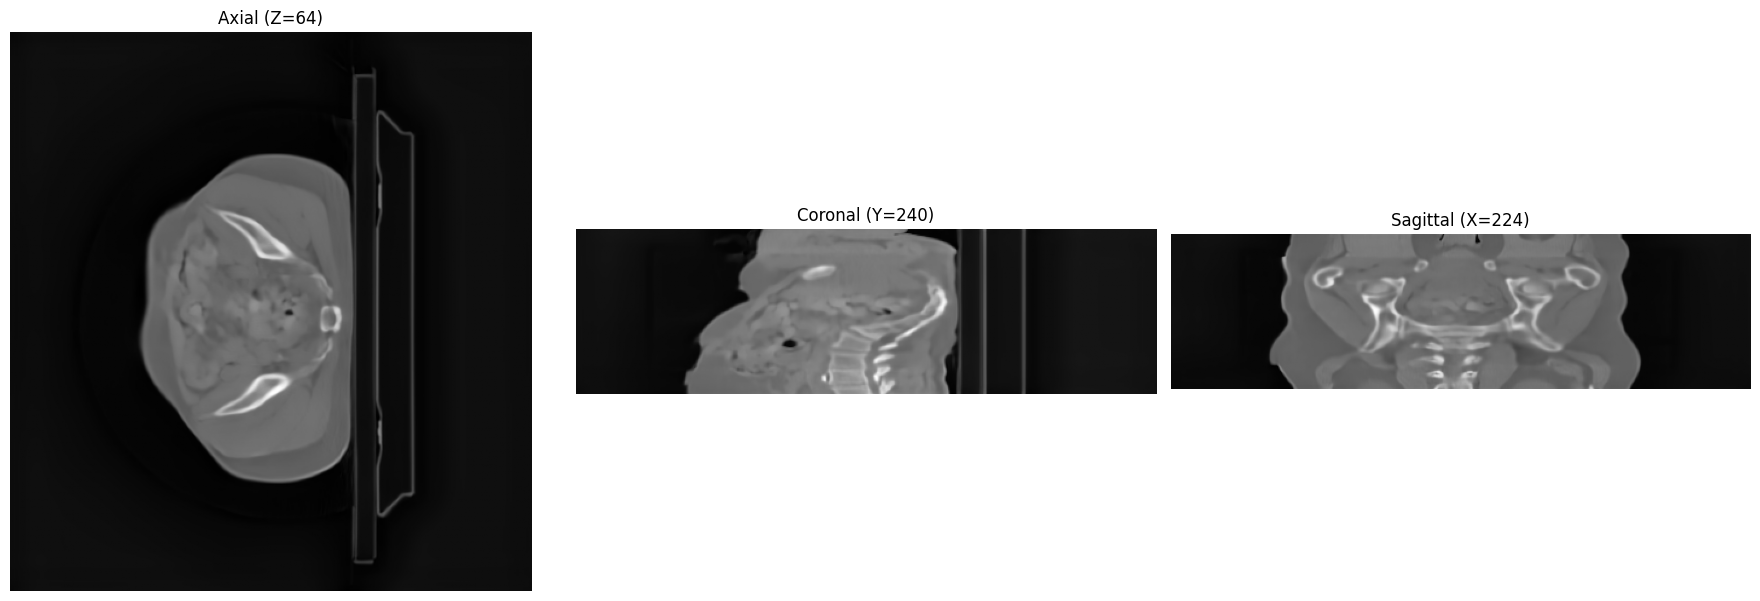

In [1]:
import sys
import torch
import nibabel as nib
import numpy as np
from argparse import Namespace


#set PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# --- 1. SETUP MAISI IMPORTS ---
# Ensure we can find the MAISI scripts
maisi_scripts_path = '/net/people/plgrid/plgpiotreksl/maisi/scripts'
if maisi_scripts_path not in sys.path:
    sys.path.append(maisi_scripts_path)

from utils import define_instance
from monai.apps.generation.maisi.networks.autoencoderkl_maisi import AutoencoderKlMaisi

vae_model_path = '/net/people/plgrid/plgpiotreksl/jupyter/models/autoencoder_epoch273.pt'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import os
if 'generated_sample' not in locals():
    latent_path = '/net/people/plgrid/plgpiotreksl/jupyter/generated_latent.pt' # Define your latent file path
    if os.path.exists(latent_path):
        generated_sample = torch.load(latent_path, map_location=device)
        print(f"✓ Loaded generated_latent from {latent_path}")
    else:
        print(f"ERROR: generated_latent not found and file does not exist at {latent_path}")



if torch.cuda.is_available():
    # Force garbage collection
    import gc
    gc.collect()
    
    # Clear CUDA cache multiple times
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    
    print(f"GPU Memory before loading latent: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
    print(f"GPU Memory reserved: {torch.cuda.memory_reserved()/1024**3:.2f} GB")
    print(f"GPU Memory free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved())/1024**3:.2f} GB")


print("Loading MAISI VAE Autoencoder...")

args_decode = Namespace()
args_decode.autoencoder_def = {
    "_target_": "monai.apps.generation.maisi.networks.autoencoderkl_maisi.AutoencoderKlMaisi",
    "spatial_dims": 3,
    "in_channels": 1,
    "out_channels": 1,
    "latent_channels": 4,
    "num_channels": [64, 128, 256],
    "num_res_blocks": [2, 2, 2],
    "norm_num_groups": 32,
    "norm_eps": 1e-06,
    "attention_levels": [False, False, False],
    "with_encoder_nonlocal_attn": False,
    "with_decoder_nonlocal_attn": False,
    "use_checkpointing": False,
    "use_convtranspose": False,
    "save_mem": True,
    "norm_float16": False,
    "num_splits": 16, 
    "dim_split": 0
}


# Initialize VAE
autoencoder_decode = define_instance(args_decode, "autoencoder_def").to(device)

# Load weights
if os.path.exists(vae_model_path):
    vae_state_dict = torch.load(vae_model_path, map_location=device)
    autoencoder_decode.load_state_dict(vae_state_dict)
    autoencoder_decode.eval()
    print("✓ VAE Model loaded successfully")
else:
    print(f"ERROR: VAE model not found at {vae_model_path}")
# --- 3. DECODE SAMPLED LATENTS ---
# Assuming 'sample' is the output tensor from the previous diffusion sampling step
# Shape should be [1, 4, 120, 120, 32] (or similar batch size)
# IMPORTANT: Unscale latents before decoding if they were scaled for diffusion
# We use the inverse of the scaling factor calculated during training
latents_to_decode = generated_sample


# Ensure shape is correct (1, 4, D, H, W)
if latents_to_decode.ndim == 4:
    print("Reshaping latents to 5D")
    latents_to_decode = latents_to_decode.unsqueeze(0)
print(f"Decoding latent shape: {latents_to_decode.shape}")
with torch.no_grad():
    with torch.cuda.amp.autocast(enabled=True):
        # model.decode() expects the latent input
        decoded_image_tensor = autoencoder_decode.decode(latents_to_decode.to(device).to(torch.float16))

print(f"Decoded image shape: {decoded_image_tensor.shape}")
# --- 4. SAVE RESULT ---
# Convert to numpy and save as NIfTI
decoded_image_np = decoded_image_tensor.squeeze().cpu().float().numpy()

output_affine = np.eye(4) 
output_path = os.path.join("/net/people/plgrid/plgpiotreksl/jupyter", "generated_image_epoch_300.nii.gz")
nib.save(nib.Nifti1Image(decoded_image_np, output_affine), output_path)
print(f"Saved generated image to: {output_path}")

import torch.nn.functional as F
import matplotlib.pyplot as plt


nx, ny, nz = decoded_image_np.shape
# Calculate middle slices for each specific dimension
slice_x = nx // 2
slice_y = ny // 2
slice_z = nz // 2
# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Axial view: Slice along Z-axis (index 2)
# Displaying X (0) vs Y (1)
axes[0].imshow(decoded_image_np[:, :, slice_z].T, cmap='gray', origin='lower')
axes[0].set_title(f"Axial (Z={slice_z})")
axes[0].axis('off')
# Coronal view: Slice along Y-axis (index 1)
# Displaying X (0) vs Z (2)
axes[1].imshow(decoded_image_np[:, slice_y, :].T, cmap='gray', origin='lower')
axes[1].set_title(f"Coronal (Y={slice_y})")
axes[1].axis('off')
# Sagittal view: Slice along X-axis (index 0)
# Displaying Y (1) vs Z (2)
axes[2].imshow(decoded_image_np[slice_x, :, :].T, cmap='gray', origin='lower')
axes[2].set_title(f"Sagittal (X={slice_x})")
axes[2].axis('off')
plt.tight_layout()
plt.show()